# **SUBMITTED BY:**

Name : NAVEEN GUPTA

Class : CSE, 4th Year

Enroll No. : 36420802723

# Assignment: Encoder, Decoder & Parameters in Large Language Models (LLM)



**Instructions:** Answer all questions. Do not use AI-generated answers. Write clean, well-commented code where required.

## Question 1

Explain the difference between Encoder-only and Decoder-only architectures with a real-world example not discussed in class.

**Answer:**

1. **Encoder-only** models read the entire input at once, with every token able to "see" every other token (before and after it). They're built to understand text, not generate it — you feed in text, get out a rich representation.

2. **Decoder-only** models generate text one token at a time, and each token can only see tokens before it (causal/autoregressive).

3. **Example**: Real-world example: a plagiarism/grammar checker (like Grammarly's core engine) needs to see a whole sentence at once to judge correctness — that's encoder-style. A smart-reply feature that finishes your sentence as you type is decoder-style, since it only has access to what's already been written.

## Question 2

Why is bidirectional context useful for text understanding? Give two NLP tasks where it is beneficial.

**Answer:**
Bidirectional context lets a model use words on both sides of a target word to resolve ambiguity, since meaning is often only clear from later context.

Two tasks:

(1) Named Entity Recognition — "Washington" is ambiguous alone, but "Washington signed the bill" (person) vs. "Washington experienced snow" (place) needs the following words.

(2) Coreference resolution — figuring out what a pronoun refers to often requires reading past it first, e.g. "Sarah told Maria that she had passed" needs the rest of the sentence to help resolve "she."

## Question 3

Why can't a Decoder see future tokens during training? Explain with an example.

**Answer:**

Because the task decoders are trained on is predicting the next token. If the model could see the answer (the actual next token) while trying to predict it, training would be trivial and useless — it would just learn to copy, not to generate. This is enforced with a causal mask in self-attention: when predicting token at position t, attention scores for positions > t are set to −∞ before softmax, so their weight becomes 0. Example: predicting "sat" in "The cat ___ on the mat" — the model must not be allowed to peek at "sat" itself during training.

## Question 4

Compare BERT and GPT in terms of architecture, training objective, input visibility, and applications.

**Answer:**

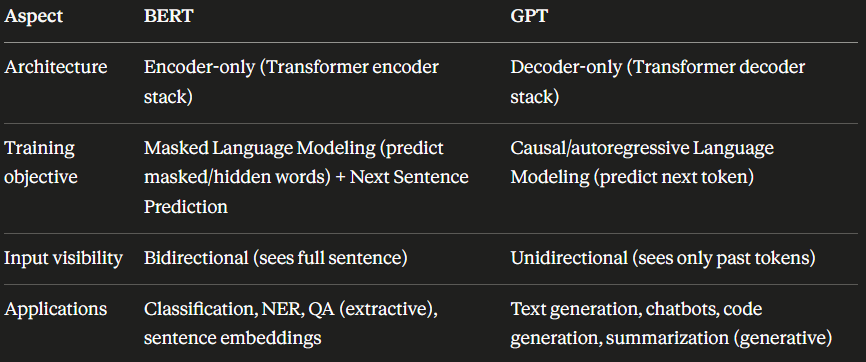

## Question 5

Draw the workflow of Encoder and Decoder using Mermaid or ASCII art.

**Answer:**

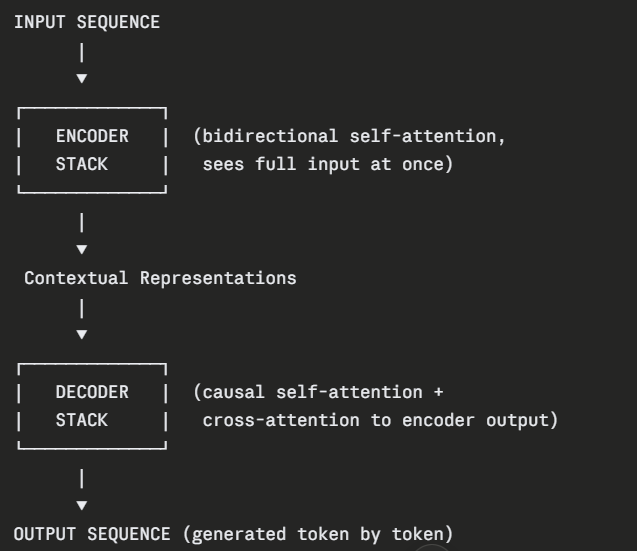

## Question 6

Predict which model (BERT or GPT) is better for: Sentiment Analysis, Chatbot, Text Summarization, Masked Word Prediction, Code Generation. Justify.

**Answer:**

Sentiment Analysis → BERT: needs full-sentence bidirectional understanding to classify polarity correctly, especially with negation/contrast.


Chatbot → GPT: needs fluent, coherent, sequential generation.


Text Summarization → GPT-style/encoder-decoder: abstractive summarization requires generation, though encoder-decoder models (T5, BART) are strongest since they read the full doc bidirectionally, then generate.


Masked Word Prediction → BERT: this is literally its pretraining objective.


Code Generation → GPT: autoregressive generation matches how code is written token-by-token with strict left-to-right dependencies.



## Question 7

What is Masked Self-Attention? Explain why it prevents cheating.

**Answer:**

Masked self-attention adds a mask to the attention score matrix that sets all positions after the current one to −∞ before the softmax, so their attention weight becomes zero. This prevents cheating because during training the entire target sequence is fed in at once for parallel efficiency — without the mask, each position could attend to (and effectively "see") the correct answer it's supposed to be predicting, making training trivial and useless for real generation, where future tokens simply don't exist at inference time.

## Question 8

Differentiate Parameters, Weights, and Biases with examples.

**Answer:**

Parameters: all learnable numbers in a model combined — weights plus biases. A "7B model" means 7 billion parameters total.


Weights: coefficients that scale each input's contribution (the W in y = Wx + b); they encode how strongly one feature influences the next layer.


Biases: the learnable offset added after the weighted sum (the b in y = Wx + b); lets the model shift output independent of input.


Example: output = w1 * x1 + w2 * x2 + b → w1, w2 are weights, b is the bias, {w1, w2, b} together are parameters.

## Question 9

If a model has 15 billion parameters stored in FP16, estimate the memory required.

**Answer:**

FP16 = 2 bytes/parameter. 15,000,000,000 × 2 = 30,000,000,000 bytes ≈ 30 GB

## Question 10

Estimate memory for a 70B parameter model in FP32.

**Answer:**

FP32 = 4 bytes/parameter. 70,000,000,000 × 4 = 280,000,000,000 bytes ≈ 280 GB — this is why 70B-class models are almost always deployed in FP16/BF16 or quantized formats instead.

## Question 11

Write Python code using transformers pipeline to perform a fill-mask task.

**Answer:**

In [1]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install -q torch torchvision torchaudio transformers

In [2]:
# import transformers
# print(transformers.__version__)

5.12.1


In [ ]:
!rm -rf ~/.cache/huggingface

In [1]:
!pip install -U transformers huggingface_hub safetensors

In [2]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")
result = fill_mask("The capital of France is [MASK].")
for r in result:
    print(f"{r['sequence']}  (score: {r['score']:.4f})")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

the capital of france is paris.  (score: 0.4168)
the capital of france is lille.  (score: 0.0714)
the capital of france is lyon.  (score: 0.0634)
the capital of france is marseille.  (score: 0.0444)
the capital of france is tours.  (score: 0.0303)


## Question 12

Write Python code using GPT-2 to generate text from a prompt.

**Answer:**

In [3]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")
output = generator(
    "Once upon a time",
    max_length=50,
    num_return_sequences=1,
    do_sample=True,
    temperature=0.8
)
print(output[0]["generated_text"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Once upon a time a king was born, the first known human was born, and the second known: a son, and not. A good name, a name, a name, a name, a name, a name. So, to give it away, if you go with it.

But they said unto him, 'What do we have in common, for we are both gods and men?' And he said, Thou shalt not say, 'No,' for I am not a child.'"

The Greeks are said to have a god named after them, for they are sons of a man.

"But what is it to be called by the name of a god, if thou hast not also the name of the Lord that is, or of one and the same God?"

"A god, for the Lord hath given thee the name of the Lord. For the name of the Lord is to be exalted. For if thou hast not the name of the Lord of hosts, or of one and the same God, thou shalt not be called Lord. And therefore, if thou hast not the name of the Lord of hosts before thee, thou shalt be called one and the same God. But thou shall be called one and the same God by the name of


## Question 14

Research Question: Compare Encoder-only, Decoder-only and Encoder-Decoder architectures in a table.

**Answer:**

## Question 15

Debug: Find and fix five possible issues in the provided BERT/GPT implementation (internet, package, model name, memory, token).

**Answer:**

Five common issues and fixes in a typical BERT/GPT script:

1. No internet access → model download fails. Fix: pre-download the model or use a local cached copy: AutoModel.from_pretrained(path, local_files_only=True).


2. Missing package (transformers not installed) → ModuleNotFoundError. Fix: pip install transformers torch.


3. Wrong/misspelled model name (e.g. "bert-base-uncase") → OSError: not found. Fix: verify exact name on huggingface.co/models, e.g. "bert-base-uncased".


4. Out-of-memory loading a large model on limited RAM/GPU. Fix: use a smaller model variant, load in FP16 (torch_dtype=torch.float16), or use device_map="auto" with accelerate.


5. Missing authentication token for gated models (e.g. LLaMA). Fix: huggingface-cli login or pass use_auth_token=True with a valid token.

## Question 17

Interview Q1: Why do larger parameter counts not always produce better performance?

**Answer:**

Larger parameter counts don't guarantee better performance because model quality also depends heavily on training data quantity/quality — the Chinchilla scaling laws showed many large models were undertrained relative to their size, meaning a smaller model trained on more/better data can outperform them. Larger models are also harder to fine-tune/align well, more prone to overfitting on small downstream datasets, slower and costlier at inference, and can hit diminishing returns or optimization instability past a certain scale.

## Question 18

Interview Q2: What happens if model weights are randomly initialized and never trained?

**Answer:**

If weights are randomly initialized and never trained, the model applies arbitrary linear transformations to any input, producing outputs that are effectively random noise — gibberish text or near-chance-level accuracy on any task. It has learned no statistical structure of language or the target domain because "training" is precisely the process of adjusting those weights based on data.

## Question 20

Mini Project: Build a notebook demonstrating BERT fill-mask and GPT text generation, compare outputs, limitations, runtime, and conclusions.

**Answer:**



In [4]:
import time
from transformers import pipeline

# BERT fill-mask
fill_mask = pipeline("fill-mask", model="bert-base-uncased")
start = time.time()
bert_out = fill_mask("Machine learning is a branch of [MASK].")
bert_time = time.time() - start

# GPT-2 generation
generator = pipeline("text-generation", model="gpt2")
start = time.time()
gpt_out = generator("Machine learning is a branch of", max_length=30, do_sample=True)
gpt_time = time.time() - start

print("BERT fill-mask top prediction:", bert_out[0]['sequence'], f"({bert_time:.2f}s)")
print("GPT-2 generated text:", gpt_out[0]['generated_text'], f"({gpt_time:.2f}s)")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BERT fill-mask top prediction: machine learning is a branch of mathematics. (0.19s)
GPT-2 generated text: Machine learning is a branch of machine learning that allows us to create new neural networks. The problem with this approach is that it is extremely difficult to create new neurons. If we want to create new neurons we need to build up a large set of connections that can be replicated and then we need to build up new connections.

This process is called "training," and it involves a small amount of training. You might have trained for a few weeks and then the training is over. You build up a bunch of connections to the training set and then you don't know how many trains you've already built up. You train the new connections back on to the training set and then again after you've built up all the connections you start to see the whole set of connections.

Then it's time to build up the other connections.

This is where the real challenge comes in.

If you're training on a set of co

In [5]:
print("BERT fill-mask top prediction:", bert_out[0]['sequence'], f"({bert_time:.2f}s)")

BERT fill-mask top prediction: machine learning is a branch of mathematics. (0.19s)


In [6]:
print("GPT-2 generated text:", gpt_out[0]['generated_text'], f"({gpt_time:.2f}s)")

GPT-2 generated text: Machine learning is a branch of machine learning that allows us to create new neural networks. The problem with this approach is that it is extremely difficult to create new neurons. If we want to create new neurons we need to build up a large set of connections that can be replicated and then we need to build up new connections.

This process is called "training," and it involves a small amount of training. You might have trained for a few weeks and then the training is over. You build up a bunch of connections to the training set and then you don't know how many trains you've already built up. You train the new connections back on to the training set and then again after you've built up all the connections you start to see the whole set of connections.

Then it's time to build up the other connections.

This is where the real challenge comes in.

If you're training on a set of connections, you need to build up the number of connections you've already built up. Y

Conclusion: BERT excels at filling in a specific gap with contextually accurate single words but can't generate free-flowing text; GPT-2 generates fluent continuations but has no bidirectional understanding and can drift off-topic. BERT inference is typically faster for single-token prediction; GPT-2 generation time scales with output length. Limitations: BERT is restricted to mask-filling, not open generation; GPT-2 can hallucinate/lose coherence over longer outputs.